## Per-segment energy-per-ASK

History (≤ 2024) is spliced from the AeroMAPS `energy_consumption_init / ask_init`
× the segment's 2024 energy/RPK shares; the projection (≥ 2025) is produced
bottom-up by the push engine from the surviving + delivered fleet. The 2024→2025
seam is smooth because both sides are now anchored on 2024.

## Fleet counts & deliveries (the push model's distinguishing state)

The push engine drives the fleet from aircraft **deliveries** and lets
retirement + utilisation curves determine the surviving fleet. Phase 5 surfaces
that native state as AeroMAPS outputs, mirroring `SimpleFleetCount`'s naming:

- `"<Segment>: Aircraft In Fleet"` — per-segment total fleet count.
- `<mid>:<aircraft_type>:aircraft_in_fleet` — per-type fleet count.
- `<mid>:<aircraft_type>:aircraft_deliveries` — per-type new deliveries per year.

**Year alignment.** Fleet counts are indexed at `last_historical_year + t`
(t = 0 is the 2024 pivot, carrying the calibrated end-2024 fleet snapshot);
deliveries at `first_projection_year + k` (2025 + k). Pre-pivot history
(2000–2023) is left NaN — the engine has no fleet state there.

### Diagnostic plots (the model's own `plot()` method)

All push charts are rendered by `PassengerAircraftEfficiencyFleetPush.plot()`,
mirroring `FleetModel.plot()`. `compute()` caches the engine's per-segment
**age-resolved** arrays (`self._engine_results`), and `plot()` draws, per segment:
the fleet / ASK / deliveries / energy stacks, the **retirement** and
**retirement-age** diagnostics (which need those internal `(periods, age, type)`
arrays, so they can't be `SingleScenarioPlot` registry plots), and the
energy-intensity curve. The matplotlib helpers live in
`fleet_model_push_visualisations.py`.

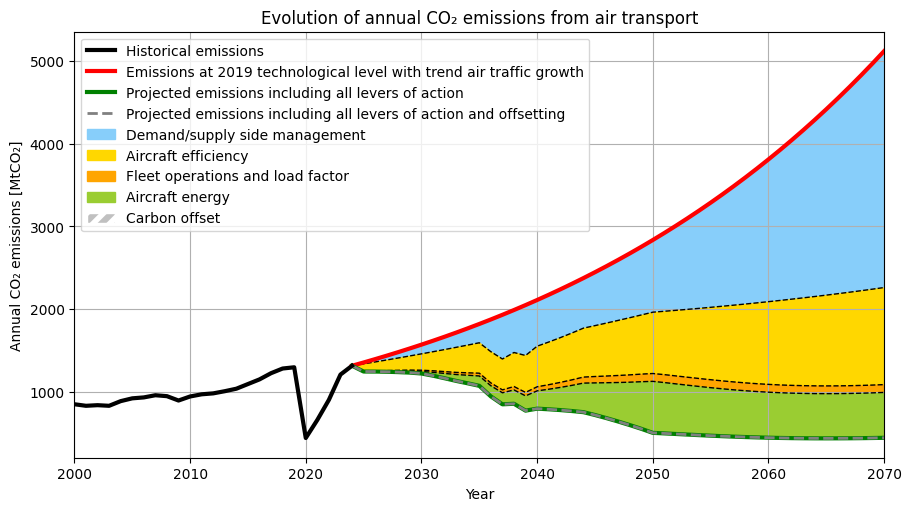

In [6]:
process.plot("air_transport_co2_emissions")

In [7]:
import tempfile
import yaml
from pathlib import Path

# The scenario markets file lives next to this notebook (CWD = notebook dir). The bad
# config is written to a temp dir, so pass markets_push.yaml as an absolute path.
markets_push = str(Path("data/markets_push.yaml").resolve())
bad_cfg = {  # no data.inputs -> prospection_start_year defaults to 2020
    "models": {
        "markets": {"markets_data_file": markets_push},
        "climate": {"climate_model_data_file": "default"},
        "energy": {
            "energy_carriers_model_data_file": "default",
            "resources_model_data_file": "default",
            "processes_model_data_file": "default",
        },
        "standards": [
            "models_traffic",
            "models_efficiency_push",
            "models_energy_without_fuel_effect",
            "models_offset",
            "models_emissions",
            "models_sustainability",
            "models_energy_cost",
            "models_operation_cost_top_down",
        ],
    },
}
with tempfile.NamedTemporaryFile("w", suffix=".yaml", delete=False) as f:
    yaml.safe_dump(bad_cfg, f)
    tmp = f.name

try:
    create_process(configuration_file=tmp)
    print("No error (unexpected).")
except ValueError as e:
    print("Guard fired as expected:\n")
    print(e)

Guard fired as expected:

PassengerAircraftEfficiencyFleetPush requires the scenario to pivot on 2024, i.e. prospection_start_year == 2025 (last_historical_year == 2024). The push engine is calibrated to the end-2024 fleet (agg_fleet_end_2024.xlsx) and the 2024 per-type ASK/MJ. Got prospection_start_year=2020 (last_historical_year=2019). Provide a 2025-pivot scenario whose historic *_init vectors run 2000-2024 (see tutorials/13_change_the_prospection_start_year/data/inputs_2025.json).
